# Modelo bidimensional simplificado do escoamento em um Backward-Facing Step via MDF

Este notebook resolve uma **Equação de Poisson bidimensional** para a componente horizontal
da velocidade em uma região afastada do degrau de um *Backward-Facing Step* (BFS).

O objetivo não é reproduzir integralmente as equações de Navier–Stokes, mas construir um
modelo didático que permita:

1. discretizar uma EDP elíptica pelo Método das Diferenças Finitas;
2. estimar o termo-fonte a partir do gradiente de pressão obtido por CFD;
3. comparar a solução do MDF com o campo de velocidade do CFD;
4. separar o erro numérico do erro decorrente da simplificação física.

O caso CFD utilizado foi adaptado para um regime laminar com aproximadamente
\(Re_H=254\).

## 1. Formulação física simplificada

Na região suficientemente afastada da recirculação, considera-se o escoamento:

- permanente;
- incompressível;
- laminar;
- predominantemente desenvolvido na direção \(x\);
- com termos convectivos desprezíveis na aproximação adotada.

A equação do momento em \(x\) é então aproximada por:

\[
\nu \nabla^2 u = \frac{\partial p}{\partial x},
\]

quando \(p\) representa a **pressão cinemática**, como ocorre normalmente no
`simpleFoam`. Assim:

\[
\frac{\partial^2 u}{\partial x^2}
+
\frac{\partial^2 u}{\partial y^2}
=
S,
\qquad
S=\frac{1}{\nu}\frac{\partial p}{\partial x}.
\]

Caso a pressão esteja em pascal, deve-se utilizar:

\[
S=\frac{1}{\mu}\frac{\partial p}{\partial x},
\qquad \mu=\rho\nu.
\]

Neste notebook, o termo-fonte é aproximado como constante e estimado na região
\(12H\leq x\leq20H\).

## 2. Discretização por diferenças finitas

Para um ponto interno \((i,j)\):

\[
\frac{u_{i+1,j}-2u_{i,j}+u_{i-1,j}}{\Delta x^2}
+
\frac{u_{i,j+1}-2u_{i,j}+u_{i,j-1}}{\Delta y^2}
=
S.
\]

A forma algébrica é:

\[
A_wu_{i-1,j}+A_eu_{i+1,j}
+A_su_{i,j-1}+A_nu_{i,j+1}
+A_pu_{i,j}=S,
\]

com:

\[
A_w=A_e=\frac{1}{\Delta x^2},
\qquad
A_s=A_n=\frac{1}{\Delta y^2},
\]

\[
A_p=-2\left(\frac{1}{\Delta x^2}+\frac{1}{\Delta y^2}\right).
\]

A solução iterativa utiliza Gauss–Seidel com relaxação sucessiva.

In [32]:
# Bibliotecas e configuração geral
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.interpolate import griddata

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = False

# Ajuste este caminho conforme a estrutura do projeto
PATH_DIR = Path.cwd().parent
PATH_DATA = PATH_DIR / "data/Re_100"
PATH_CFD = PATH_DIR / 'bfs2dData/postProcessing' # diretório dos dados CFD
DATASET_PATH = PATH_DATA / "dataset_bfs_2d_grid.csv"

print("Dataset esperado em:", DATASET_PATH)

Dataset esperado em: /home/matheus/Documentos/Mestrado/modelagem_computacional/bfsDifFinitas/data/Re_100/dataset_bfs_2d_grid.csv


## Processamento dos dados CFD

In [13]:
# -------------------------------------------------
# Utilidades
# -------------------------------------------------

def latest_dir(base: Path) -> Path:
    """Retorna o diretório do último 'tempo'."""
    times = sorted(
        [p for p in base.iterdir() if p.is_dir()],
        key=lambda p: float(p.name)
    )
    return times[-1]


def load_case(case_dir: str, file_name: str) -> pd.DataFrame:
    """
    Carrega o {file_name} do último tempo do caso.
    """
    case = Path(case_dir)
    tdir = latest_dir(case)

    fpath = tdir / file_name
    if not fpath.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {fpath}")
    
    df = pd.read_csv(fpath)
    df = df.rename(columns={
        "U_0":"Ux",
        "U_1":"Uy",
        "U_2":"Uz"
    })

    return df

# -------------------------------------------------
# Main
# -------------------------------------------------
profiles = ["grid"]
for bfs_profile in profiles:
    print(f"Lendo caso BFS laminar perfis x/h={bfs_profile.split('_')[-1]} ...")
    df = load_case(PATH_CFD / "sample", f"{bfs_profile}_p_U.csv")
    df = df.drop(columns=["z", "Uz"])
    df = df[["x", "y", "Ux", "Uy", "p"]]

    out_name = f"dataset_bfs_2d_{bfs_profile}.csv"
    df.to_csv(PATH_DATA / out_name, index=False)
    print(f"Dataset salvo em: {out_name}")
    print("Total de amostras:", len(df))

profiles = ["x_by_h_1", "x_by_h_2", "x_by_h_4", "x_by_h_6", "x_by_h_8",
            "x_by_h_10", "x_by_h_12", "x_by_h_15", "x_by_h_20",
            "x_by_h_25", "x_by_h_30", "x_by_h_40"]
for bfs_profile in profiles:
    print(f"Lendo caso BFS laminar perfis x/h={bfs_profile.split('_')[-1]} ...")
    df = load_case(PATH_CFD / "sample", f"{bfs_profile}_p_U.csv")
    df = df[["y", "Ux", "Uy", "p"]]

    out_name = f"dataset_bfs_2d_{bfs_profile}.csv"
    df.to_csv(PATH_DATA / out_name, index=False)
    print(f"Dataset salvo em: {out_name}")
    print("Total de amostras:", len(df))

Lendo caso BFS laminar perfis x/h=grid ...
Dataset salvo em: dataset_bfs_2d_grid.csv
Total de amostras: 100975
Lendo caso BFS laminar perfis x/h=1 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_1.csv
Total de amostras: 114
Lendo caso BFS laminar perfis x/h=2 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_2.csv
Total de amostras: 114
Lendo caso BFS laminar perfis x/h=4 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_4.csv
Total de amostras: 114
Lendo caso BFS laminar perfis x/h=6 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_6.csv
Total de amostras: 114
Lendo caso BFS laminar perfis x/h=8 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_8.csv
Total de amostras: 114
Lendo caso BFS laminar perfis x/h=10 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_10.csv
Total de amostras: 114
Lendo caso BFS laminar perfis x/h=12 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_12.csv
Total de amostras: 114
Lendo caso BFS laminar perfis x/h=15 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_15.csv
Total de amostras: 114
Lendo caso 

# Parâmetros do Problema

In [36]:
# Parâmetros físicos do caso adaptado
H = 0.0127                 # altura do degrau [m]
U_INLET = 44.2             # velocidade de entrada usada no CFD [m/s]
RE_H = 100.0
NU = U_INLET * H / RE_H    # viscosidade cinemática [m²/s]

# Configuração da pressão exportada pelo OpenFOAM
PRESSURE_IS_KINEMATIC = True
RHO = 1.0                  # usado somente se p estiver em Pa
MU = RHO * NU

print(f"nu calculado = {NU:.6e} m²/s")
print(f"Re calculado = {U_INLET * H / NU:.2f}")

nu calculado = 5.613400e-03 m²/s
Re calculado = 100.00


In [37]:
# Leitura e validação básica do dataset CFD
df = pd.read_csv(DATASET_PATH)

required_columns = {"x", "y", "Ux", "Uy", "p"}
missing = required_columns.difference(df.columns)
if missing:
    raise ValueError(f"Colunas ausentes no dataset: {sorted(missing)}")

df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=list(required_columns))

print(df[list(required_columns)].describe().T)
print(f"\nNúmero de pontos válidos: {len(df):,}")

       count        mean         std        min        25%         50%  \
y   100975.0    0.061698    0.030716    0.00000   0.035490    0.062108   
Uy  100975.0   -0.097712    0.439472   -1.82142  -0.169853   -0.015353   
p   100975.0  253.019772  306.855472 -115.14200   9.768030  122.261000   
x   100975.0   -0.479543    0.667885   -1.65100  -1.060030   -0.469060   
Ux  100975.0   42.549650   16.000248   -1.71574  35.362750   47.234800   

           75%        max  
y     0.088204    0.11430  
Uy    0.080602    1.65479  
p   440.732000  905.77300  
x     0.112747    0.63500  
Ux   54.692800   61.00180  

Número de pontos válidos: 100,975


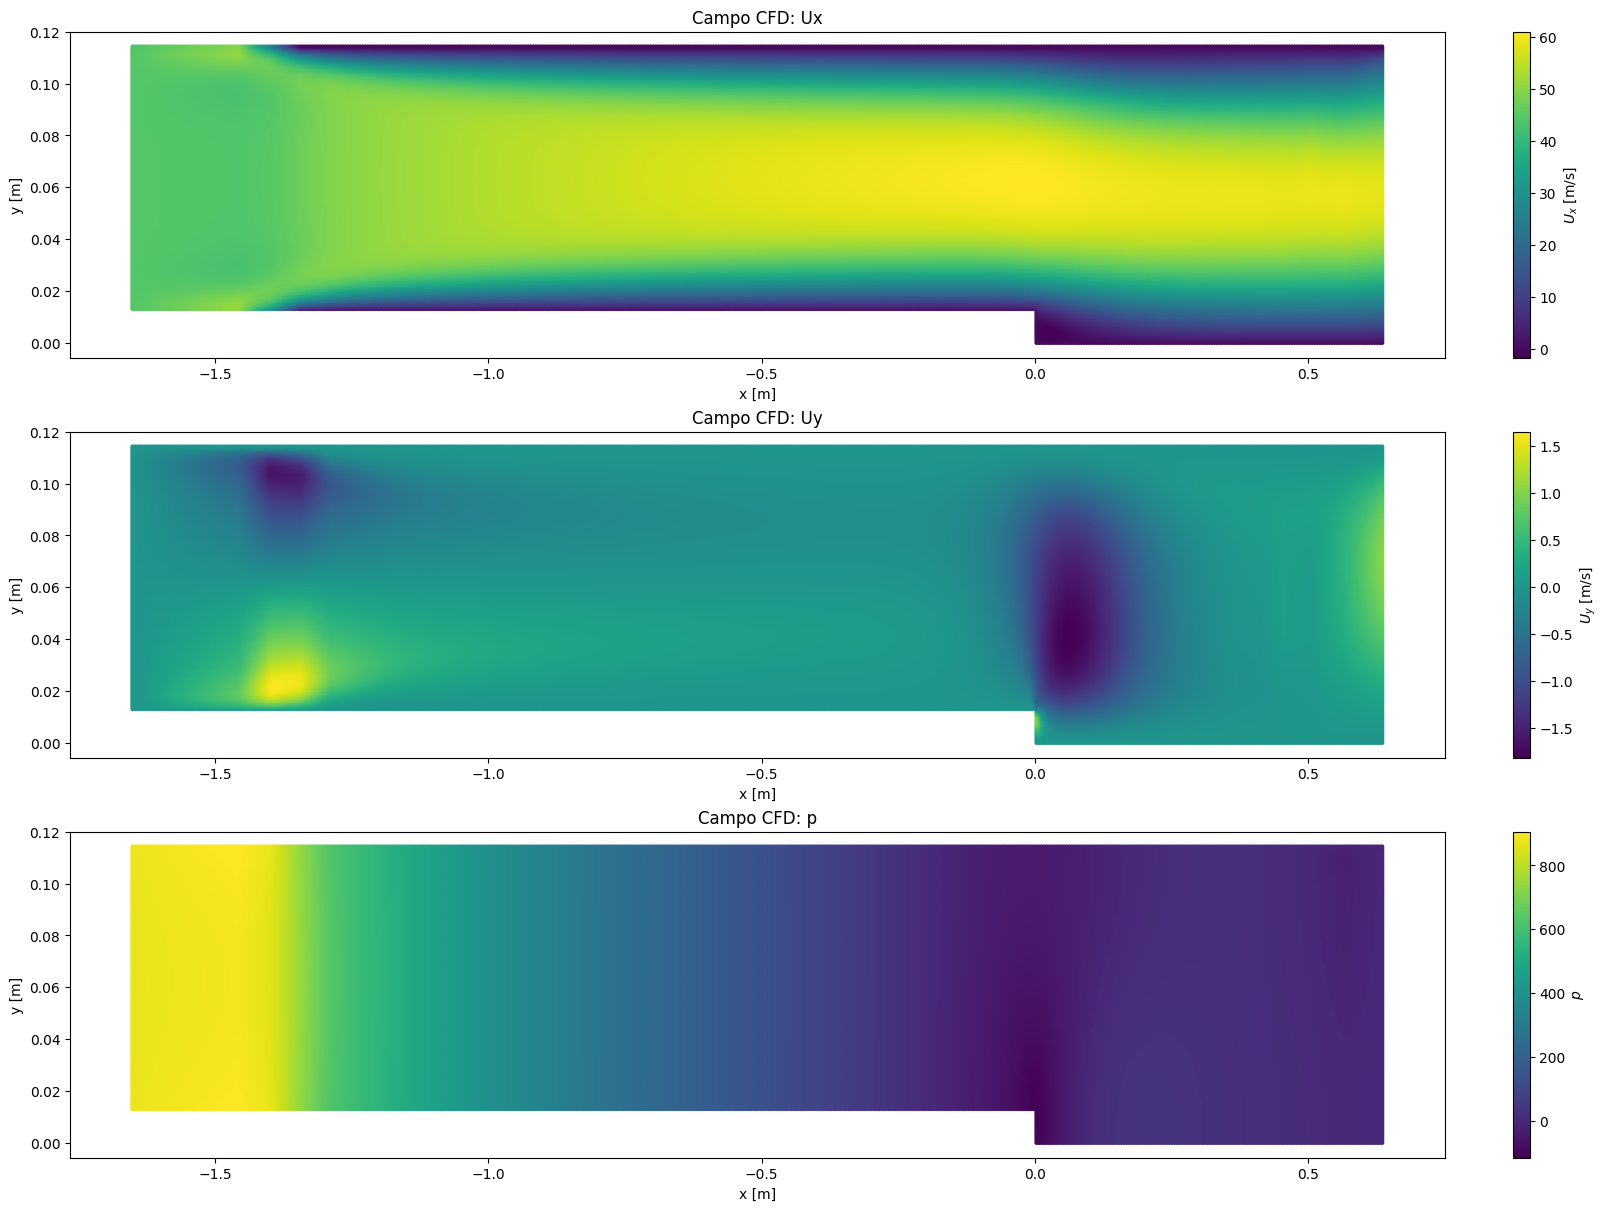

In [38]:
# Visualização inicial dos campos CFD
fig, axes = plt.subplots(3, 1, figsize=(16, 12), constrained_layout=True)

fields = [
    ("Ux", r"$U_x$ [m/s]"),
    ("Uy", r"$U_y$ [m/s]"),
    ("p", r"$p$"),
]

for ax, (field, label) in zip(axes, fields):
    sc = ax.scatter(df["x"], df["y"], c=df[field], s=4)
    fig.colorbar(sc, ax=ax, label=label)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(f"Campo CFD: {field}")

plt.show()

## 3. Definição do subdomínio de comparação

A EDP simplificada não é aplicada sobre toda a geometria do BFS. A comparação é limitada à
região afastada do degrau:

$$
12H\leq x\leq20H.
$$

Essa escolha reduz a influência direta da separação, recirculação e reanexação. O domínio
utilizado pelo MDF é retangular e compreende toda a altura do canal disponível nessa região.

In [40]:
# Subdomínio afastado da recirculação
XH_MIN = 20.0
XH_MAX = 40.0

x_min = XH_MIN * H
x_max = XH_MAX * H

df_region = df[
    (df["x"] >= x_min) &
    (df["x"] <= x_max)
].copy()

if df_region.empty:
    raise ValueError("O recorte 12H–20H não contém pontos. Verifique as coordenadas do dataset.")

y_min = df_region["y"].min()
y_max = df_region["y"].max()

print(f"Subdomínio x: [{x_min:.6f}, {x_max:.6f}] m")
print(f"Subdomínio y: [{y_min:.6f}, {y_max:.6f}] m")
print(f"Pontos CFD no recorte: {len(df_region):,}")

Subdomínio x: [0.254000, 0.508000] m
Subdomínio y: [0.000000, 0.114300] m
Pontos CFD no recorte: 12,320


## 4. Estimativa do gradiente de pressão e do termo-fonte

A pressão do CFD é primeiro reduzida a uma pressão média por estação em \(x\). Em seguida,
ajusta-se uma reta:


$\bar p(x) \approx {ax+b}$,


de modo que:

$\frac{\partial p}{\partial x}\approx {a}$.

O termo-fonte constante é então calculado usando ($\nu$) ou ($\mu$), conforme a unidade da
pressão exportada.

x mínimo = 0.254764 m
x máximo = 0.506727 m
x/H = 20.06 até 39.90
dp/dx = -8.246270e+01
S = -1.469033e+04


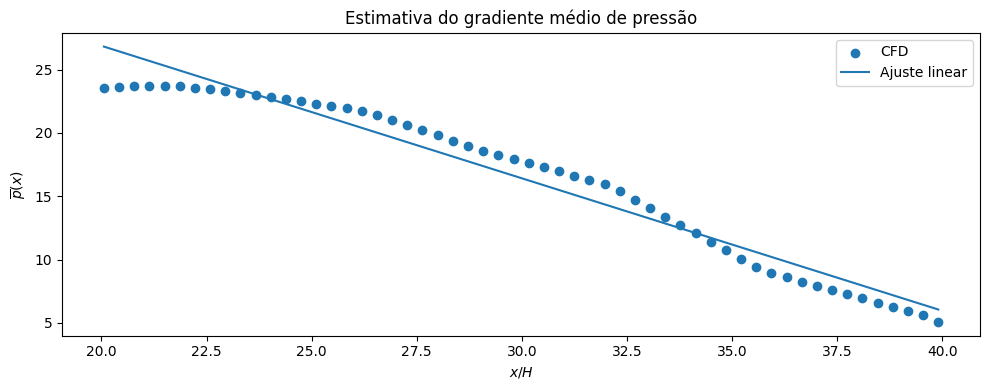

In [41]:
df_region = df_region.copy()
df_region["x_m"] = df_region["x"].round(8)

pressure_profile = (
    df_region.groupby("x_m", as_index=False)["p"]
    .mean()
    .rename(columns={"p": "p_mean"})
    .sort_values("x_m")
)

x_m = pressure_profile["x_m"].to_numpy()
p_mean = pressure_profile["p_mean"].to_numpy()

# Gradiente em relação a x dimensional [m]
dpdx, intercept = np.polyfit(x_m, p_mean, deg=1)

if PRESSURE_IS_KINEMATIC:
    SOURCE = dpdx / NU
else:
    SOURCE = dpdx / MU

p_fit = dpdx * x_m + intercept

print(f"x mínimo = {x_m.min():.6f} m")
print(f"x máximo = {x_m.max():.6f} m")
print(f"x/H = {x_m.min()/H:.2f} até {x_m.max()/H:.2f}")
print(f"dp/dx = {dpdx:.6e}")
print(f"S = {SOURCE:.6e}")

plt.figure(figsize=(10, 4))
plt.scatter(x_m / H, p_mean, label="CFD")
plt.plot(x_m / H, p_fit, label="Ajuste linear")
plt.xlabel(r"$x/H$")
plt.ylabel(r"$\overline{p}(x)$")
plt.title("Estimativa do gradiente médio de pressão")
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
channel_height = y_max - y_min
u_max_cfd = np.nanmax(df["Ux"])

source_from_velocity = -8.0 * u_max_cfd / channel_height**2

print(f"S obtido da pressão:    {SOURCE:.6e}")
print(f"S exigido pelo perfil: {source_from_velocity:.6e}")
print(f"Razão: {SOURCE/source_from_velocity:.4f}")

S obtido da pressão:    -1.469033e+04
S exigido pelo perfil: -3.735426e+04
Razão: 0.3933


## 5. Malha MDF e condições de contorno

São adotadas as seguintes condições:

- paredes inferior e superior: \(u=0\);
- fronteira esquerda: perfil de \(U_x\) interpolado do CFD em \(x=25H\);
- fronteira direita: perfil de \(U_x\) interpolado do CFD em \(x=40H\).

O uso dos perfis CFD nas fronteiras laterais permite avaliar principalmente a capacidade da
EDP simplificada de reconstruir o campo **no interior** do subdomínio.

In [43]:
def interpolate_cfd_to_grid(df_source, X, Y, field="Ux"):
    ''' Interpola um campo CFD não estruturado para uma malha regular.'''
    points = df_source[["x", "y"]].to_numpy()
    values = df_source[field].to_numpy()

    field_linear = griddata(points, values, (X, Y), method="linear")

    # Preenchimento de pontos eventualmente fora do casco convexo
    if np.isnan(field_linear).any():
        field_nearest = griddata(points, values, (X, Y), method="nearest")
        field_linear = np.where(np.isnan(field_linear), field_nearest, field_linear)

    return field_linear


def build_problem(df_source, nx=161, ny=81):
    x = np.linspace(x_min, x_max, nx)
    y = np.linspace(y_min, y_max, ny)
    X, Y = np.meshgrid(x, y, indexing="ij")

    Ux_cfd = interpolate_cfd_to_grid(df_source, X, Y, field="Ux")

    u = np.zeros((nx, ny), dtype=float)

    # Condições nas fronteiras laterais obtidas do CFD
    u[0, :] = Ux_cfd[0, :]
    u[-1, :] = Ux_cfd[-1, :]

    # No-slip nas paredes
    u[:, 0] = 0.0
    u[:, -1] = 0.0

    # Inicialização por interpolação linear entre entrada e saída
    for i in range(1, nx - 1):
        weight = i / (nx - 1)
        u[i, :] = (1.0 - weight) * u[0, :] + weight * u[-1, :]
        u[i, 0] = 0.0
        u[i, -1] = 0.0

    return x, y, X, Y, Ux_cfd, u

In [44]:
def compute_residual(u, dx, dy, source):
    residual = np.zeros_like(u)

    source_internal = (
        source[1:-1, 1:-1]
        if np.ndim(source) == 2
        else source
    )

    residual[1:-1, 1:-1] = (
        (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1]) / dx**2
        + (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2]) / dy**2
        - source_internal
    )

    return residual

def solve_poisson_sor(
    u_initial,
    x,
    y,
    source,
    omega=1.7,
    tolerance_update=1e-8,
    tolerance_residual=1e-4,
    max_iter=50_000,
    report_every=500,
):
    ''' Resolve $\nabla^2 u} = source por Gauss–Seidel com SOR.'''
    if not (0.0 < omega < 2.0):
        raise ValueError("omega deve pertencer ao intervalo (0, 2).")

    u = u_initial.copy()
    dx = x[1] - x[0]
    dy = y[1] - y[0]

    aw = ae = 1.0 / dx**2
    ass = an = 1.0 / dy**2
    ap = -2.0 * (1.0 / dx**2 + 1.0 / dy**2)

    history = []

    for iteration in range(1, max_iter + 1):
        max_update = 0.0

        for i in range(1, len(x) - 1):
            for j in range(1, len(y) - 1):
                u_gs = (
                    source[i,j]
                    - aw * u[i - 1, j]
                    - ae * u[i + 1, j]
                    - ass * u[i, j - 1]
                    - an * u[i, j + 1]
                ) / ap

                old_value = u[i, j]
                u[i, j] = (1.0 - omega) * old_value + omega * u_gs
                max_update = max(max_update, abs(u[i, j] - old_value))

        # As condições de contorno permanecem fixas
        residual = compute_residual(u, dx, dy, source)
        max_residual = np.max(np.abs(residual[1:-1, 1:-1]))

        history.append((iteration, max_update, max_residual))

        if iteration % report_every == 0 or (
            max_update < tolerance_update and max_residual < tolerance_residual
        ):
            print(
                f"Iter {iteration:6d} | "
                f"atualização = {max_update:.3e} | "
                f"resíduo = {max_residual:.3e}"
            )

        if max_update < tolerance_update and max_residual < tolerance_residual:
            print(f"Convergência atingida em {iteration} iterações.")
            break
    else:
        print("Aviso: o número máximo de iterações foi atingido.")

    history = pd.DataFrame(
        history,
        columns=["iteration", "max_update", "max_residual"],
    )

    return u, history

In [45]:
# Construção e solução do problema principal
NX = 161
NY = 81

x, y, X, Y, Ux_cfd, u0 = build_problem(
    df_region,
    nx=NX,
    ny=NY,
)

xi = (x - x.min()) / (x.max() - x.min())
eta = (y - y.min()) / (y.max() - y.min())

XI, ETA = np.meshgrid(xi, eta, indexing="ij")

C = -1.0
SOURCE = np.full_like(XI, C, dtype=float)

u_mdf, convergence_history = solve_poisson_sor(
    u_initial=u0,
    x=xi,
    y=eta,
    source=SOURCE,
    omega=1.7,
    tolerance_update=1e-8,
    tolerance_residual=1e-4,
    max_iter=50_000,
    report_every=500,
)

print(f"\nMDF: min={u_mdf.min():.6f}, max={u_mdf.max():.6f}")
print(f"CFD: min={Ux_cfd.min():.6f}, max={Ux_cfd.max():.6f}")

Iter    500 | atualização = 2.390e-02 | resíduo = 1.354e+02
Iter   1000 | atualização = 4.138e-03 | resíduo = 2.344e+01
Iter   1500 | atualização = 7.147e-04 | resíduo = 4.049e+00
Iter   2000 | atualização = 1.234e-04 | resíduo = 6.992e-01
Iter   2500 | atualização = 2.131e-05 | resíduo = 1.207e-01
Iter   3000 | atualização = 3.680e-06 | resíduo = 2.085e-02
Iter   3500 | atualização = 6.354e-07 | resíduo = 3.600e-03
Iter   4000 | atualização = 1.097e-07 | resíduo = 6.216e-04
Iter   4500 | atualização = 1.895e-08 | resíduo = 1.073e-04
Iter   4682 | atualização = 9.997e-09 | resíduo = 5.664e-05
Convergência atingida em 4682 iterações.

MDF: min=0.000000, max=59.227600
CFD: min=0.000000, max=59.227600


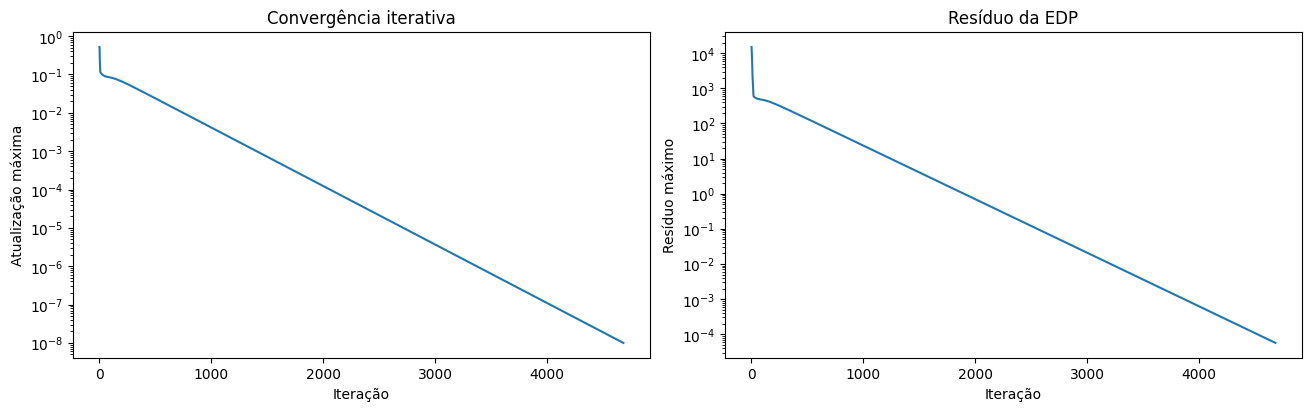

In [46]:
# Histórico de convergência
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

axes[0].semilogy(
    convergence_history["iteration"],
    convergence_history["max_update"],
)
axes[0].set_xlabel("Iteração")
axes[0].set_ylabel("Atualização máxima")
axes[0].set_title("Convergência iterativa")

axes[1].semilogy(
    convergence_history["iteration"],
    convergence_history["max_residual"],
)
axes[1].set_xlabel("Iteração")
axes[1].set_ylabel("Resíduo máximo")
axes[1].set_title("Resíduo da EDP")

plt.show()

## 6. Comparação dos campos

As métricas dimensionais preservam a magnitude física da velocidade. Também são calculadas
métricas normalizadas usando uma **única escala de referência**, definida pelo maior valor
absoluto do CFD.

In [47]:
def calculate_metrics(reference, prediction, mask=None):
    if mask is None:
        mask = np.isfinite(reference) & np.isfinite(prediction)

    ref = reference[mask]
    pred = prediction[mask]
    error = pred - ref

    denominator = np.linalg.norm(ref)

    return {
        "MAE": np.mean(np.abs(error)),
        "RMSE": np.sqrt(np.mean(error**2)),
        "L2_rel": np.linalg.norm(error) / denominator if denominator > 0 else np.nan,
        "Linf": np.max(np.abs(error)),
    }


# Excluir as fronteiras da avaliação principal
interior_mask = np.ones_like(u_mdf, dtype=bool)
interior_mask[[0, -1], :] = False
interior_mask[:, [0, -1]] = False

metrics_dimensional = calculate_metrics(
    reference=Ux_cfd,
    prediction=u_mdf,
    mask=interior_mask,
)

U_REF = np.max(np.abs(Ux_cfd[interior_mask]))
Ux_cfd_norm = Ux_cfd / U_REF
u_mdf_norm = u_mdf / U_REF

metrics_normalized = calculate_metrics(
    reference=Ux_cfd_norm,
    prediction=u_mdf_norm,
    mask=interior_mask,
)

metrics_table = pd.DataFrame(
    [metrics_dimensional, metrics_normalized],
    index=["Dimensional", "Normalizado"],
)

display(metrics_table)

,MAE,RMSE,L2_rel,Linf
Dimensional,16.652243,19.634485,0.450908,34.499358
Normalizado,0.281172,0.331528,0.450908,0.582520


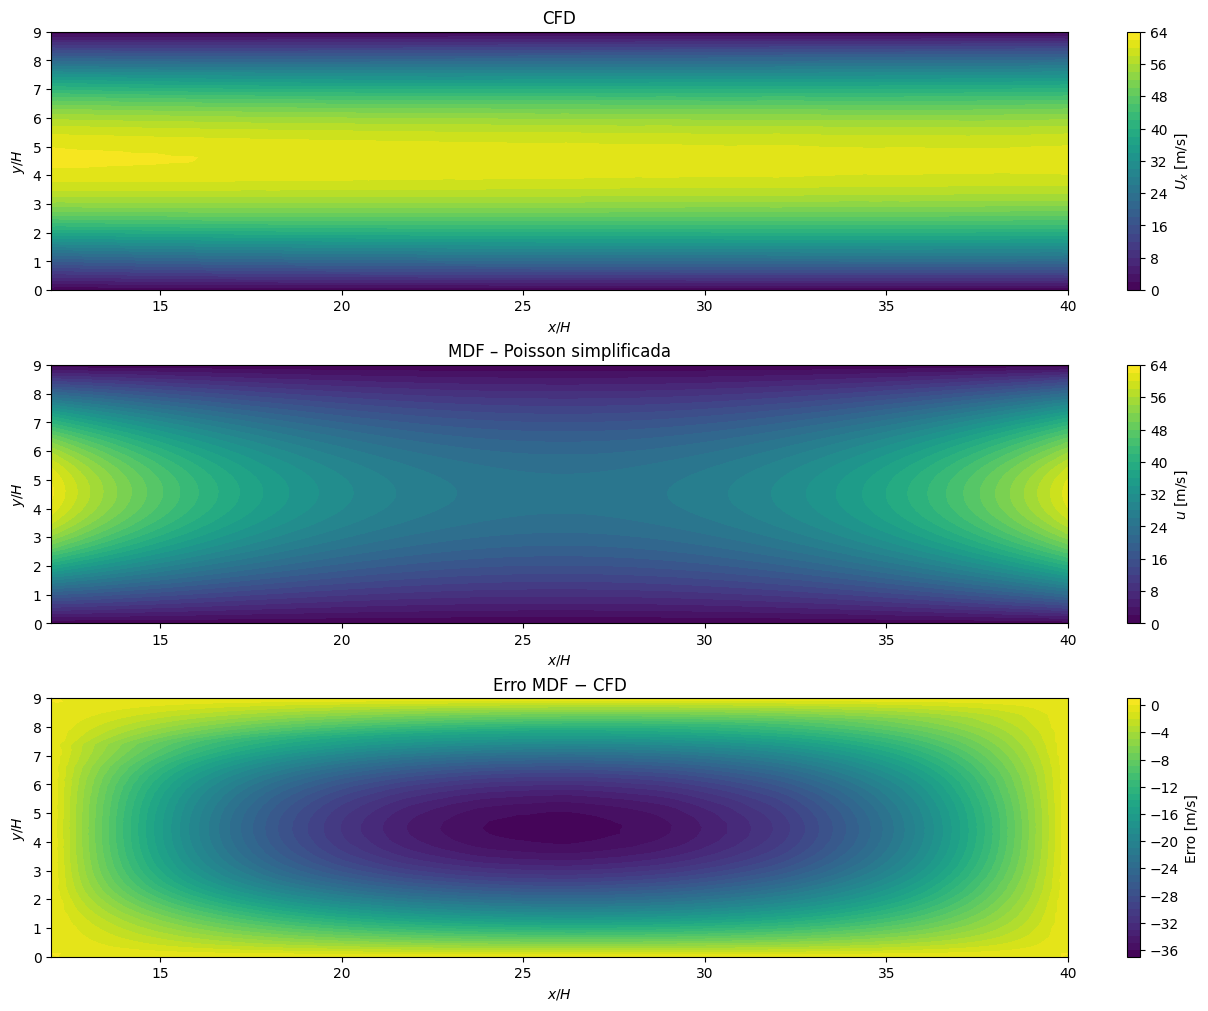

In [31]:
# Campos CFD, MDF e erro dimensional
error_field = u_mdf - Ux_cfd

fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

field_specs = [
    (Ux_cfd, "CFD", r"$U_x$ [m/s]"),
    (u_mdf, "MDF – Poisson simplificada", r"$u$ [m/s]"),
    (error_field, "Erro MDF − CFD", "Erro [m/s]"),
]

for ax, (field, title, label) in zip(axes, field_specs):
    contour = ax.contourf(X / H, Y / H, field, levels=40)
    fig.colorbar(contour, ax=ax, label=label)
    ax.set_xlabel(r"$x/H$")
    ax.set_ylabel(r"$y/H$")
    ax.set_title(title)

plt.show()

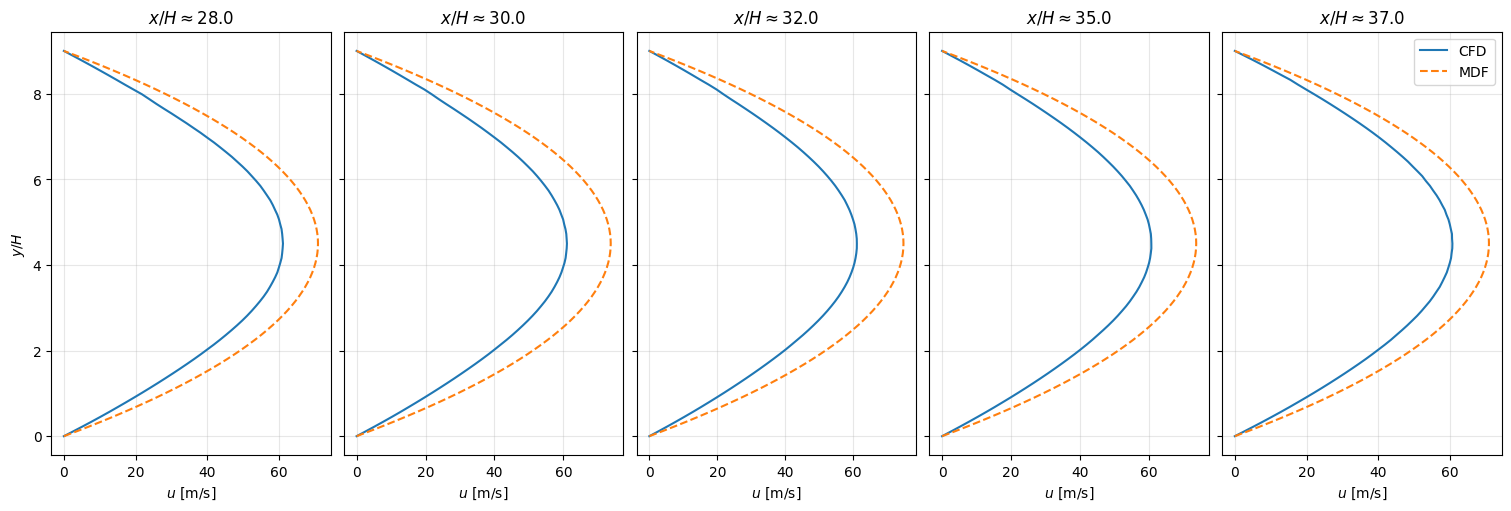

In [85]:
# Comparação de perfis em estações internas
stations_xh = [28, 30, 32, 35, 37]

fig, axes = plt.subplots(
    1,
    len(stations_xh),
    figsize=(15, 5),
    sharey=True,
    constrained_layout=True,
)

for ax, station_xh in zip(axes, stations_xh):
    index = np.argmin(np.abs(x / H - station_xh))

    ax.plot(Ux_cfd[index, :], y / H, label="CFD")
    ax.plot(u_mdf[index, :], y / H, "--", label="MDF")
    ax.set_xlabel(r"$u$ [m/s]")
    ax.set_title(fr"$x/H\approx{x[index]/H:.1f}$")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"$y/H$")
axes[-1].legend()
plt.show()

## 7. Estudo opcional de refinamento de malha

A convergência em relação ao CFD não representa apenas erro de discretização. Mesmo com uma
malha refinada, pode permanecer um erro associado à remoção dos termos convectivos e à hipótese
de termo-fonte constante.

Por isso, o refinamento deve ser interpretado juntamente com:

1. a redução do resíduo da EDP;
2. a diferença entre soluções MDF sucessivas;
3. o erro em relação ao CFD.

In [14]:
def run_mesh_study(meshes, df_source, source):
    results = []

    for nx, ny in meshes:
        print(f"\n--- Malha {nx} x {ny} ---")

        x_h, y_h, X_h, Y_h, cfd_h, u0_h = build_problem(
            df_source,
            nx=nx,
            ny=ny,
        )

        mdf_h, hist_h = solve_poisson_sor(
            u_initial=u0_h,
            x=x_h,
            y=y_h,
            source=source,
            omega=1.7,
            tolerance_update=1e-8,
            tolerance_residual=1e-4,
            max_iter=50_000,
            report_every=2_000,
        )

        mask_h = np.ones_like(mdf_h, dtype=bool)
        mask_h[[0, -1], :] = False
        mask_h[:, [0, -1]] = False

        metrics_h = calculate_metrics(cfd_h, mdf_h, mask_h)

        results.append({
            "Nx": nx,
            "Ny": ny,
            "dx": x_h[1] - x_h[0],
            "dy": y_h[1] - y_h[0],
            "iterations": int(hist_h["iteration"].iloc[-1]),
            **metrics_h,
        })

    return pd.DataFrame(results)


# Descomente para executar o estudo de refinamento.
# O custo cresce rapidamente porque o solver é iterativo em Python puro.
#
mesh_results = run_mesh_study(
    meshes=[(41, 21), (81, 41), (161, 81)],
    df_source=df_region,
    source=SOURCE,
)
display(mesh_results)


--- Malha 41 x 21 ---
Iter    241 | atualização = 2.808e-09 | resíduo = 9.828e-05
Convergência atingida em 241 iterações.

--- Malha 81 x 41 ---
Iter   1002 | atualização = 7.438e-10 | resíduo = 9.884e-05
Convergência atingida em 1002 iterações.

--- Malha 161 x 81 ---
Iter   2000 | atualização = 1.554e-07 | resíduo = 8.174e-02
Iter   4000 | atualização = 2.197e-10 | resíduo = 1.156e-04
Iter   4045 | atualização = 1.896e-10 | resíduo = 9.969e-05
Convergência atingida em 4045 iterações.


,Nx,Ny,dx,dy,iterations,MAE,RMSE,L2_rel,Linf
0,41,21,0.002540,0.005715,241,0.013189,0.016636,0.016647,0.035445
1,81,41,0.001270,0.002857,1002,0.013876,0.017328,0.017567,0.036898
2,161,81,0.000635,0.001429,4045,0.013606,0.017189,0.017537,0.037286


## 8. Interpretação dos resultados

A solução obtida deve ser interpretada como uma aproximação difusiva local do campo de
velocidade. Diferenças em relação ao CFD podem resultar de:

- desprezo dos termos convectivos;
- aproximação de \(\partial p/\partial x\) por um valor constante;
- influência residual da recuperação do escoamento após o degrau;
- condições de contorno simplificadas;
- interpolação do campo CFD;
- erro de discretização do MDF.

Assim, o objetivo principal não é obter coincidência exata com o CFD, mas demonstrar a
discretização e a solução de uma EDP bidimensional em um contexto fisicamente inspirado no BFS.